In [1]:
from src.objetos import Dados, camada_densa, rede_neural, gradiente_conjugado

In [2]:
# Caminho dos dados e dos rotulos
caminho_dados = r"dados/imageMNIST.csv"
caminho_rotulos = r"dados/labelMNIST.csv"

dados = Dados(caminho_dados=caminho_dados, caminho_rotulos=caminho_rotulos)


In [3]:
# Escolha do método de separação dos dados
dados._holdout(0.6, 0.2)

In [4]:
# Parâmetros da nossa rede neural
epocas = 500
taxa_aprendizado = 2
lambda_reg = 0.01
arquitetura_camadas = [400, 25, 10]

In [5]:
#Treinamento da rede com otimização por meio do método do Gradiente Conjugado
import numpy as np

epocas = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
custos = []

for max_it in epocas:
    camadas = []

    for i in range(len(arquitetura_camadas)-2):
        camada = camada_densa.CamadaDensa(
            tamanho_entrada=arquitetura_camadas[i], 
            tamanho_saida=arquitetura_camadas[i+1],
            funcao_de_ativacao='sigmoid'
            )
        camadas.append(camada)
    # Aplica softmax na ultima camada
    camada = camada_densa.CamadaDensa(
            tamanho_entrada=arquitetura_camadas[-2], 
            tamanho_saida=arquitetura_camadas[-1],
            funcao_de_ativacao='softmax'
            )
    camadas.append(camada)

    # Inicialização da rede neural
    rede = rede_neural.RedeNeural(camadas=camadas,funcao_de_custo="entropia_cruzada", regularizador_lambda=lambda_reg)

    otimizador = gradiente_conjugado.GradienteConjugado(rede, max_it, lambda_reg)
    custo = otimizador.treino(dados.conjunto_treinamento[0], dados.conjunto_treinamento[1])
    custos.append(custo)

Treinamento concluído. Sucesso: False. Motivo: Maximum number of iterations has been exceeded.

[[0.09779216 0.09775698 0.0949853  ... 0.09907045 0.09932888 0.09956276]
 [0.10375543 0.10307043 0.10263082 ... 0.10071215 0.10620804 0.10338514]
 [0.08874873 0.09035422 0.09075104 ... 0.08884946 0.08664847 0.08673879]
 ...
 [0.10095694 0.09909908 0.09507575 ... 0.09581397 0.09882374 0.09951642]
 [0.10520512 0.10316837 0.10558646 ... 0.10472657 0.10512858 0.10476495]
 [0.08953663 0.091575   0.09008103 ... 0.09314614 0.08951683 0.09086675]]

2.296382706951162
Treinamento concluído. Sucesso: False. Motivo: Maximum number of iterations has been exceeded.

[[0.03138982 0.01992933 0.08446491 ... 0.03689209 0.39502936 0.02466979]
 [0.05794743 0.1072428  0.04533824 ... 0.0785728  0.03116798 0.08015344]
 [0.02482378 0.02241165 0.04774919 ... 0.10559306 0.03308716 0.09469769]
 ...
 [0.07576366 0.09827964 0.19618561 ... 0.14875441 0.08320987 0.1373569 ]
 [0.10579226 0.06003727 0.23323965 ... 0.1655069

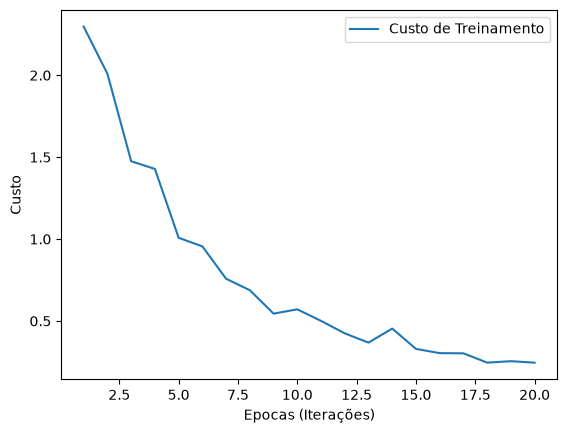

In [6]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(epocas,custos, label="Custo de Treinamento")
plt.xlabel("Epocas (Iterações)")
plt.ylabel("Custo")
plt.legend()
plt.show()

In [7]:
#Treinamento da rede com otimização por meio do método do Gradiente Conjugado
import numpy as np

acuracy_CG = []

# Parâmetros da nossa rede neural
epocas = 500
taxa_aprendizado = 2
lambda_reg = [0.25,0.5,0.75,1,1.25,1.5,1.75,2,2.25,3,5,7,10]
arquitetura_camadas = [400, 25, 10]

for lambda_i in lambda_reg:
    camadas = []
    
    for i in range(len(arquitetura_camadas)-2):
        camada = camada_densa.CamadaDensa(
            tamanho_entrada=arquitetura_camadas[i], 
            tamanho_saida=arquitetura_camadas[i+1],
            funcao_de_ativacao='sigmoid'
            )
        camadas.append(camada)
    # Aplica softmax na ultima camada
    camada = camada_densa.CamadaDensa(
            tamanho_entrada=arquitetura_camadas[-2], 
            tamanho_saida=arquitetura_camadas[-1],
            funcao_de_ativacao='softmax'
            )
    camadas.append(camada)
    # Inicialização da rede neural
    rede = rede_neural.RedeNeural(camadas=camadas,funcao_de_custo="entropia_cruzada", regularizador_lambda=lambda_i)

    otimizador = gradiente_conjugado.GradienteConjugado(rede, epocas, lambda_i)
    custo = otimizador.treino(dados.conjunto_treinamento[0], dados.conjunto_treinamento[1])

    y_teste = rede._avalia(dados.conjunto_teste[0])
    classes_pred = np.argmax(y_teste, axis=0) + 1
    classes_real = np.argmax(dados.conjunto_teste[1], axis=0) + 1
    acertos = np.sum(classes_pred == classes_real)
    num_amostras = dados.conjunto_teste[0].shape[1]

    acuracia_modelo = acertos/num_amostras

    acuracy_CG.append(acuracia_modelo)
    

Iteração 10
Iteração 20
Iteração 30
Iteração 40
Iteração 50
Iteração 60
Iteração 70
Iteração 80
Iteração 90
Iteração 100
Iteração 110
Iteração 120
Iteração 130
Iteração 140
Iteração 150
Iteração 160
Iteração 170
Iteração 180
Iteração 190
Iteração 200
Iteração 210
Iteração 220
Iteração 230
Iteração 240
Iteração 250
Iteração 260
Iteração 270
Iteração 280
Iteração 290
Iteração 300
Iteração 310
Iteração 320
Iteração 330
Iteração 340
Iteração 350
Iteração 360
Iteração 370
Iteração 380
Iteração 390
Iteração 400
Iteração 410
Iteração 420
Iteração 430
Iteração 440
Iteração 450
Iteração 460
Iteração 470
Iteração 480
Iteração 490
Iteração 500
Treinamento concluído. Sucesso: False. Motivo: Maximum number of iterations has been exceeded.

[[1.26386172e-04 4.09670727e-05 1.67342740e-07 ... 1.16584183e-05
  9.93982403e-01 2.27400255e-05]
 [1.88182689e-04 2.72624601e-04 2.24672247e-07 ... 1.22466164e-07
  2.20921513e-03 1.04106658e-04]
 [2.54749489e-05 1.03467986e-05 9.87856476e-08 ... 1.90539077e-05

In [8]:
import numpy as np

acuracy_ML = []

# Parâmetros da nossa rede neural
epocas = 500
taxa_aprendizado = 2
lambda_reg = [0.25,0.5,0.75,1,1.25,1.5,1.75,2,2.25,3,5,7,10]
arquitetura_camadas = [400, 25, 10]

for lambda_i in lambda_reg:
    camadas = []
    
    for i in range(len(arquitetura_camadas)-2):
        camada = camada_densa.CamadaDensa(
            tamanho_entrada=arquitetura_camadas[i], 
            tamanho_saida=arquitetura_camadas[i+1],
            funcao_de_ativacao='sigmoid'
            )
        camadas.append(camada)
    # Aplica softmax na ultima camada
    camada = camada_densa.CamadaDensa(
            tamanho_entrada=arquitetura_camadas[-2], 
            tamanho_saida=arquitetura_camadas[-1],
            funcao_de_ativacao='softmax'
            )
    camadas.append(camada)
    # Inicialização da rede neural
    rede = rede_neural.RedeNeural(camadas=camadas,funcao_de_custo="entropia_cruzada", regularizador_lambda=lambda_i)

    rede.treinar(
        epocas=epocas,
        taxa_aprendizado=taxa_aprendizado,
        conjunto_treinamento=dados.conjunto_treinamento,
        conjunto_validacao=dados.conjunto_validacao,
        regularizador_lambda=lambda_i
    )

    y_teste = rede._avalia(dados.conjunto_teste[0])
    classes_pred = np.argmax(y_teste, axis=0) + 1
    classes_real = np.argmax(dados.conjunto_teste[1], axis=0) + 1
    acertos = np.sum(classes_pred == classes_real)
    num_amostras = dados.conjunto_teste[0].shape[1]
    
    acuracia_modelo = acertos/num_amostras
    
    acuracy_ML.append(acuracia_modelo)

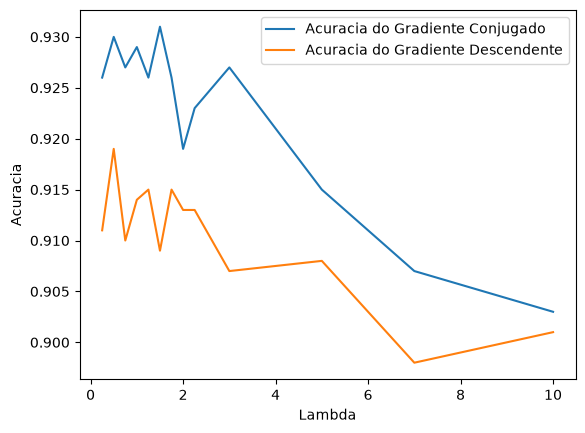

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(lambda_reg,acuracy_CG, label="Acuracia do Gradiente Conjugado")
plt.plot(lambda_reg,acuracy_ML, label="Acuracia do Gradiente Descendente")
plt.xlabel("Lambda")
plt.ylabel("Acuracia")
plt.legend()
plt.show()